# EDA - khám phá dữ liệu dạng bảng

## Import các thư viện cần thiết

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

from scipy import stats
from pyampute.exploration.mcar_statistical_tests import MCARTest
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer

## Đọc dữ liệu

In [9]:
# Name of columns
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Read file
DATA_PATH = "../data/tabular-data/"
train_df = pd.read_csv(DATA_PATH + 'raw/adult.data', names=column_names, sep=',', skipinitialspace=True)
test_df = pd.read_csv(DATA_PATH + 'raw/adult.test', names=column_names, sep=',', skipinitialspace=True, skiprows=1)

print(train_df.shape)
train_df.head()

(32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


**Insights:**

- Bộ train có **32,561 dòng** và **15 cột**, phù hợp mô tả chuẩn của Adult dataset.
- Dữ liệu gồm cả biến số và biến phân loại, nên pipeline tiền xử lý cần tách riêng 2 nhóm đặc trưng.
- Cần xử lý ký hiệu thiếu `?` trước khi làm các kiểm định thống kê để tránh sai lệch kết quả.

In [10]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


**Insights:**

- Dữ liệu có **32561** dòng và **15** cột.

- Mỗi dòng đại diện cho thông tin nhân khẩu học của một cá nhân.

- Ý nghĩa của các cột (thuộc tính) là:

    - `age`: Tuổi của cá nhân.

    - `workclass`: Loại công việc của cá nhân

    - `fnlwgt`: Trọng số cuối cùng, đại diện cho số lượng người mà dòng dữ liệu đại diện trong dân số thực tế.

    - `education`: Trình độ học vấn.

    - `education-num`: Số năm đi học tương úng với trình độ học vấn ở dạng số.

    - `marital-status`: Tình trạng hôn nhân.

    - `occupation`: Nghề nghiệp cụ thể.

    - `relationship`: Mối quan hệ trong gia đình.

    - `race`: Chủng tộc.

    - `sex`: Giới tính.

    - `capital-gain`: Thu nhập từ việc bán tài sản.

    - `capital-loss`: Khoản lỗ từ việc bán tài sản.

    - `hours-per-week`: Số giờ làm việc trung bình mỗi tuần.

    - `native-country`: Quốc gia quê quán.

    - `income`: Tổng thu nhập - Biến mục tiêu. 

# Biểu đồ phân phối của các biến dữ liệu

### Phân phối của biến mục tiêu `income`

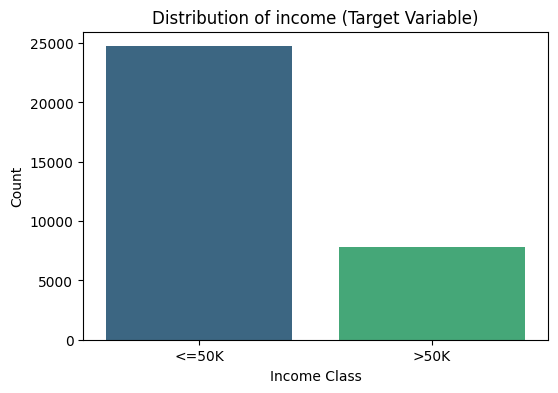

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=train_df, palette='viridis', hue='income', legend=False)
plt.title('Distribution of income (Target Variable)')
plt.xlabel('Income Class')
plt.ylabel('Count')
plt.show()

**Insights:**

- Dữ liệu bị mất cân bằng (Imbalanced data) giữa các lớp. Lớp **<=50K** chiếm tỉ lệ lớn so với lớp **>50K**.

### Biểu đồ phân phối của các cột có dữ liệu số

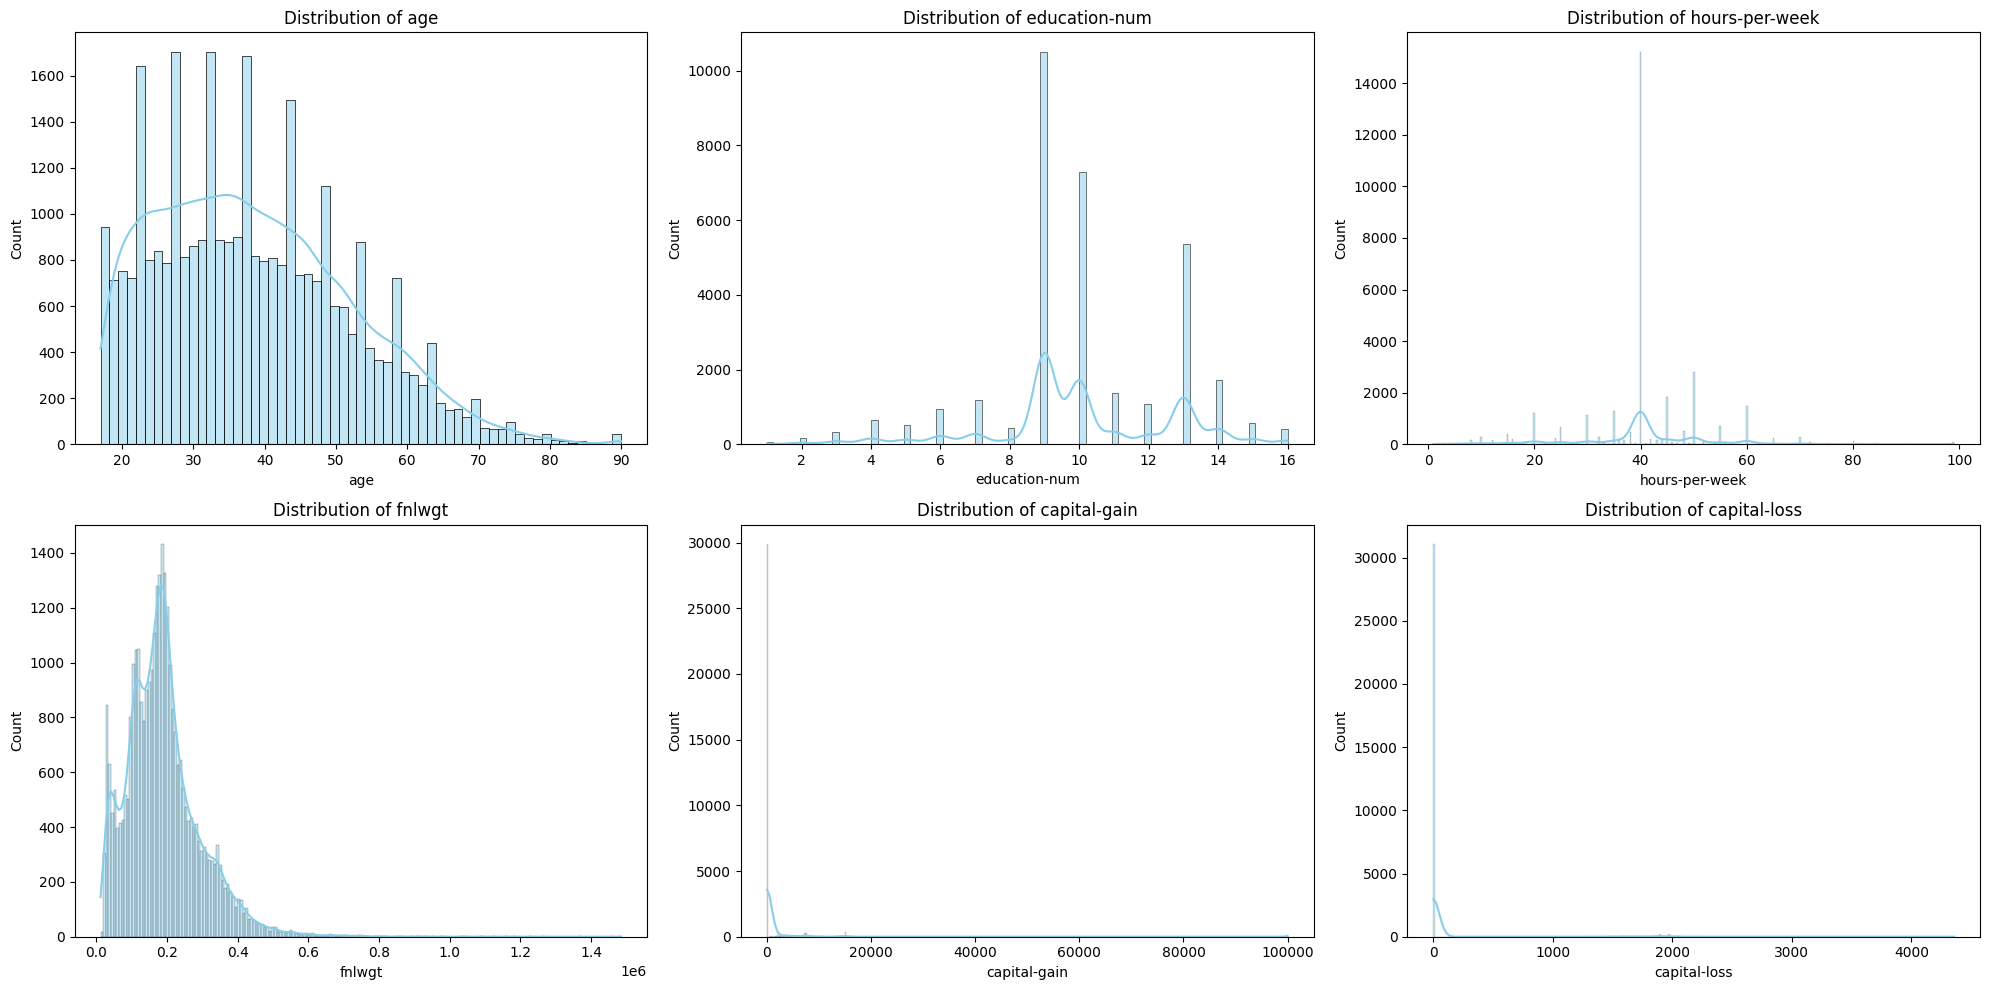

In [12]:
# Numeric features to plot
num_features = ['age', 'education-num', 'hours-per-week', 'fnlwgt', 'capital-gain', 'capital-loss']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
for i, col in enumerate(num_features):
    sns.histplot(train_df[col], kde=True, ax=axes.flat[i], color='skyblue')
    axes.flat[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

**Insights:**

- Phân phối tuổi (age):

    - Dữ liệu có dạng lệch phải (Right-skewed). Phần lớn các cá nhân nằm trong độ tuổi từ 20 đến 50. Số lượng người lao động giảm dần khi độ tuổi tăng cao (sau 60 tuổi).

- Số năm đi học (education-num):

    - Dữ liệu không liên tục mà tập trung thành các cột nhọn (multimodal). Đỉnh cao nhất nằm ở mức 9 (tương ứng với HS-grad) và các mức 10, 13.

- Số giờ làm việc mỗi tuần (hours-per-week):

    - Có cột cao nhất ngay tại giá trị 40. Điều này phản ánh thực tế thị trường lao động với chế độ làm việc 40 giờ/tuần.

- Trọng số cuối cùng (fnlwgt):

    - Đây là biểu đồ có độ lệch phải rất cực đoan. Hầu hết các giá trị tập trung ở mức thấp, nhưng có một vài "đuôi" kéo dài đến tận 1.4 triệu.

- Lợi nhuận và Thua lỗ vốn (capital-gain & capital-loss):

    - Hầu hết các giá trị đều tập trung ở 0. 

### Biểu đồ phân phối của các cột dữ liệu phân loại

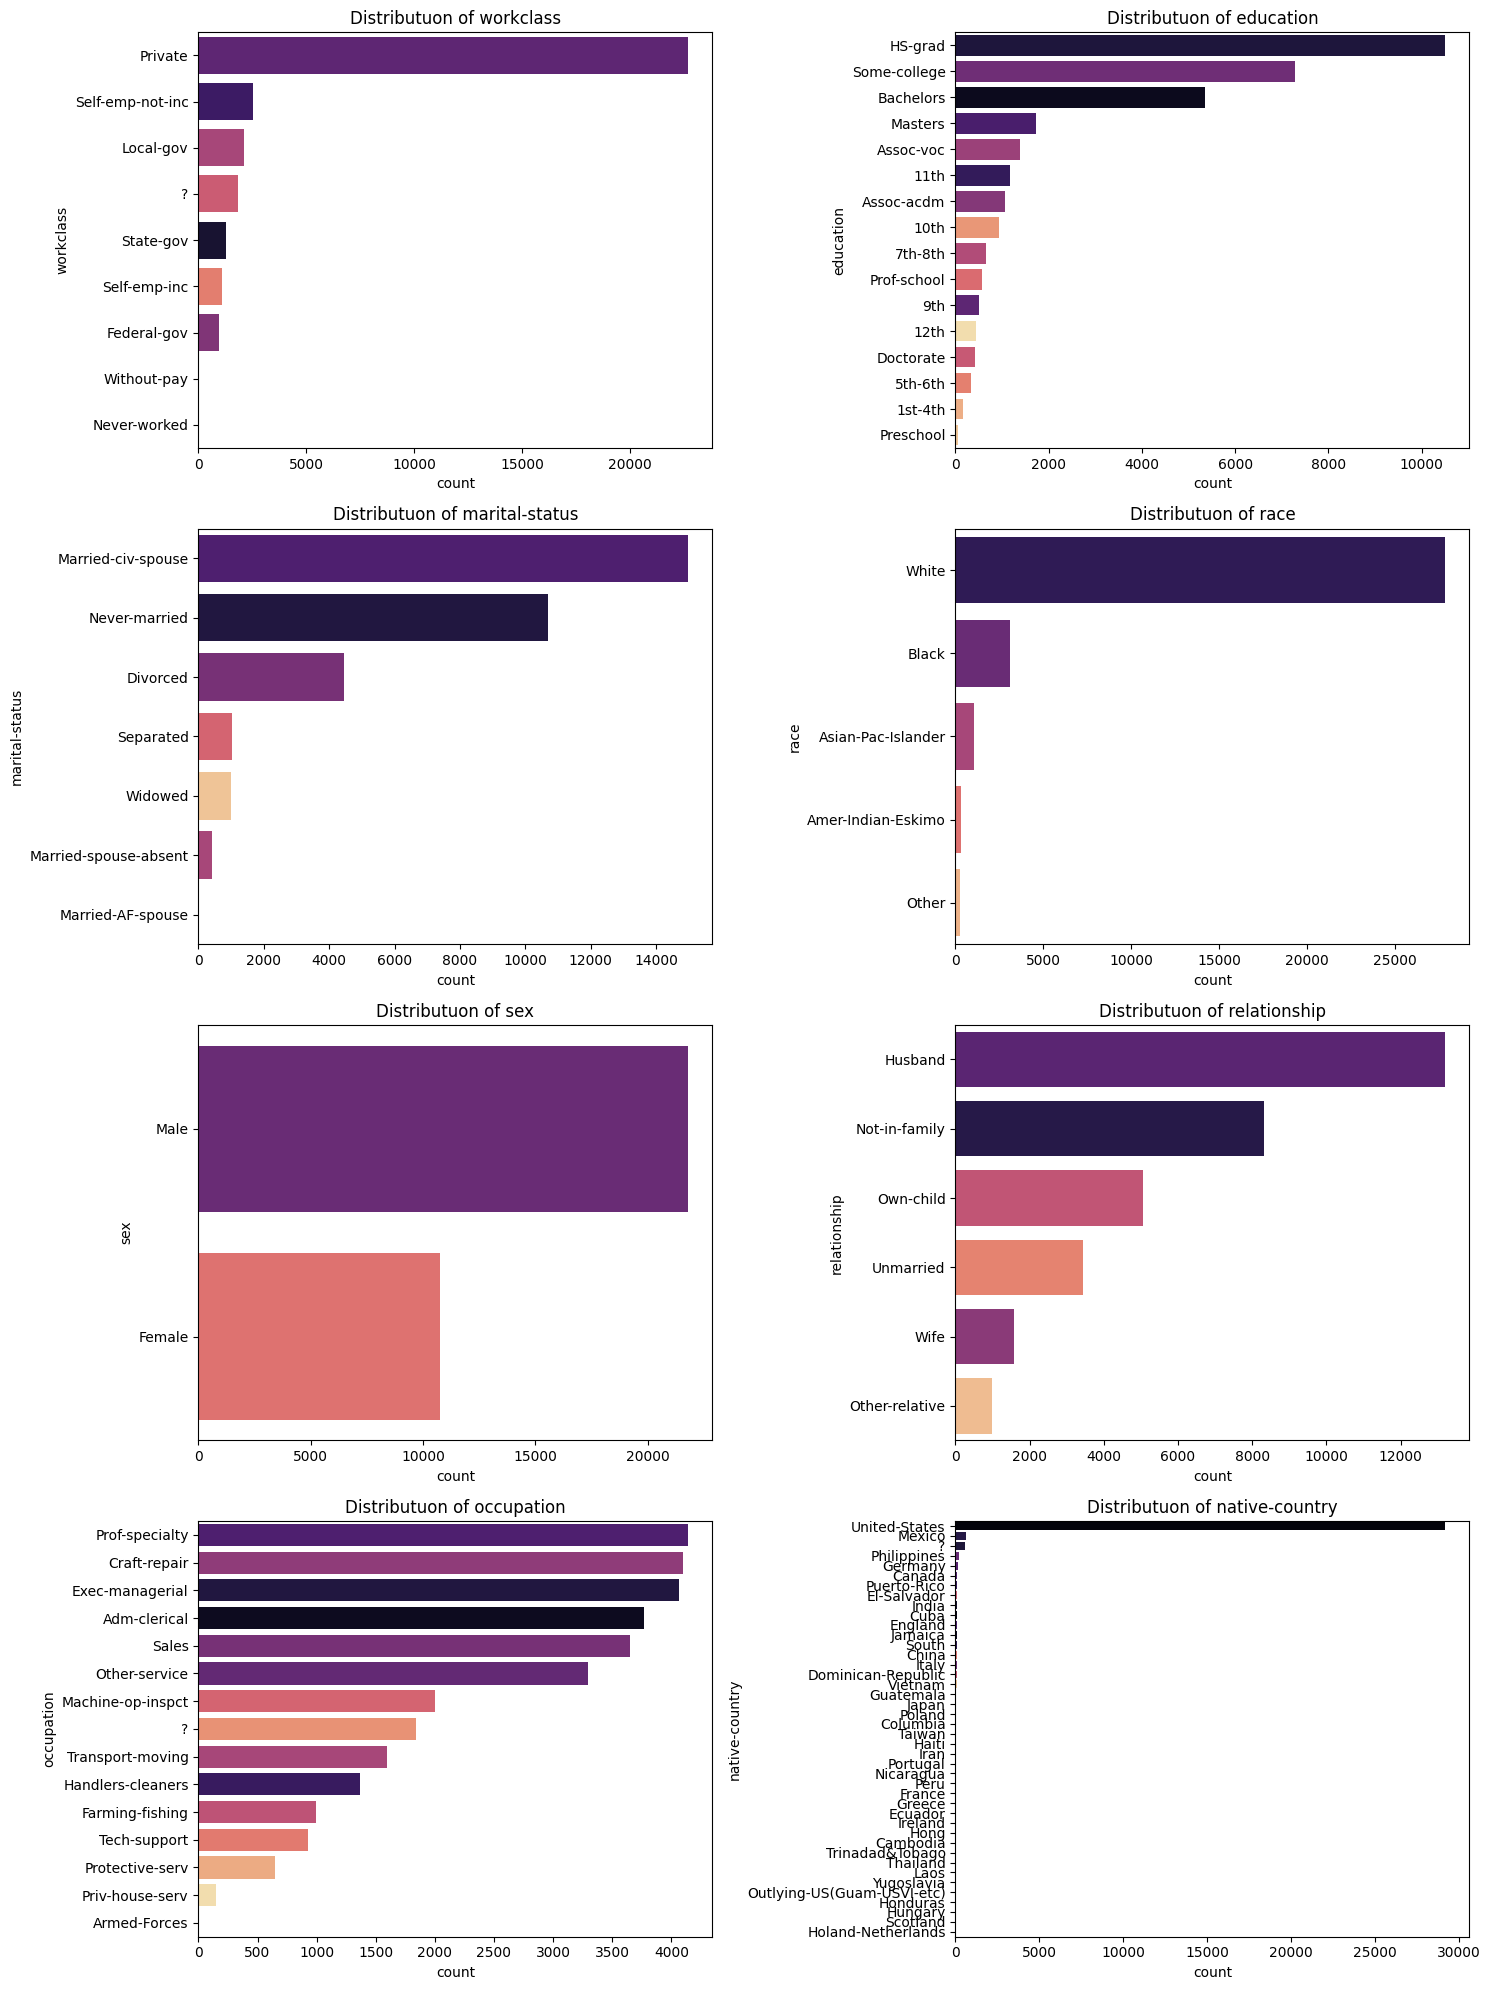

In [13]:
cat_features = ['workclass', 'education', 'marital-status', 'race', 'sex', 'relationship', 'occupation', 'native-country']

plt.figure(figsize=(15, 20))
for i, col in enumerate(cat_features):
    plt.subplot(4, 2, i+1)
    sns.countplot(y=col, data=train_df, order=train_df[col].value_counts().index, hue=col, palette='magma')
    plt.title(f'Distributuon of {col}')
    plt.tight_layout()

plt.show()

**Insights:**

- `Workclass`: bị lệch rất mạnh về nhóm Private, các nhóm còn lại chiếm tỷ trọng nhỏ.

- `Education`: tập trung cao ở HS-grad, Some-college và Bachelors; các bậc rất thấp hoặc rất cao là nhóm hiếm.

- `Marital-status`: chủ yếu là Married-civ-spouse và Never-married, tạo ra 2 cụm dân số lớn khá rõ.

- `Race`: mất cân bằng rất nặng, nhóm White áp đảo; các nhóm khác là thiểu số rõ rệt.

- `Sex`: **Male** nhiều hơn **Female** đáng kể.

## Kiểm tra các giá trị thiếu (Mising values)

In [14]:
# Replace '?' with NaN
train_df.replace('?', np.nan, inplace=True)

# Number of missing values in each column
print("Number of missing values in each column")
print(train_df.isnull().sum())

Number of missing values in each column
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


**Insights:**

- Giá trị thiếu tập trung ở ba cột: `occupation`, `workclass`, và `native-country`.
- Tỷ lệ thiếu không quá lớn nhưng đủ ảnh hưởng đến mô hình nếu loại bỏ toàn bộ dòng.
- Nên ưu tiên chiến lược bù thiếu có điều kiện (group-wise imputation hoặc model-based imputation) thay vì drop đơn giản.

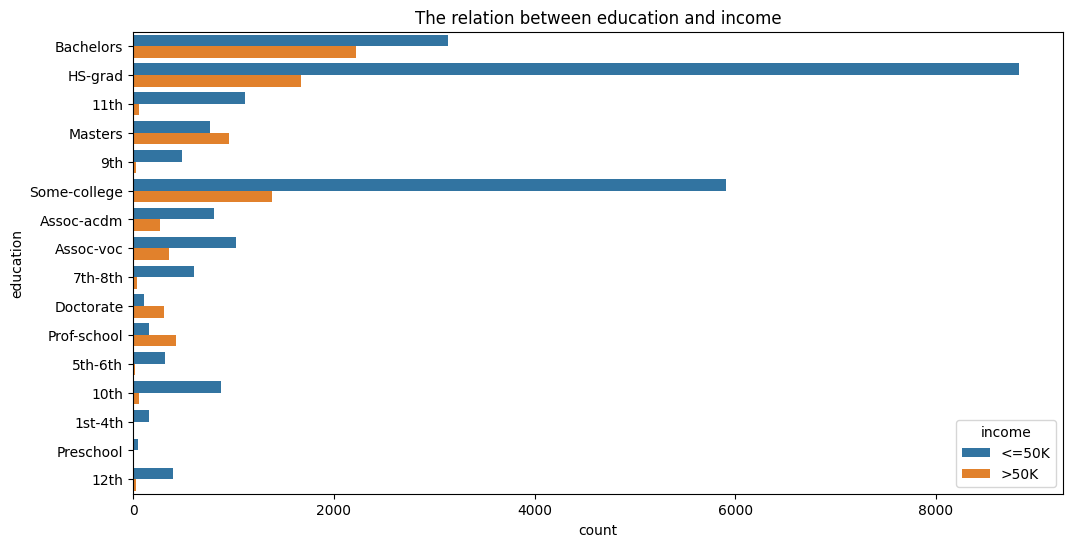

In [15]:
# The relation between education and income
plt.figure(figsize=(12,6))
sns.countplot(y='education', hue='income', data=train_df)
plt.title('The relation between education and income')
plt.show()

**Insights:**

- Nhóm có trình độ học vấn cao hơn (Bachelors, Masters, Doctorate) có xu hướng xuất hiện nhiều hơn ở lớp thu nhập `>50K`.
- Các nhóm học vấn thấp tập trung chủ yếu ở lớp `<=50K`.
- `education` là đặc trưng có giá trị dự báo tốt cho bài toán phân loại thu nhập.

# 2.2.2. Phân tích thống kê khám phá (EDA chuyên sâu)

## a. Kiểm định phân phối cho từng thuộc tính số.

In [16]:
# a) Distribution test for each numeric feature.
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in train_df.columns if c not in numeric_cols]
alpha = 0.05
dist_rows = []

for col in numeric_cols:
    x = train_df[col].dropna().astype(float)
    n = len(x)

    if n <= 5000:
        test_name = "Shapiro-Wilk"
        stat, p_value = stats.shapiro(x)
    else:
        test_name = "D'Agostino-Pearson"
        stat, p_value = stats.normaltest(x)

    is_normal = p_value > alpha
    scaler_reco = "StandardScaler" if is_normal else "RobustScaler or QuantileTransformer"

    dist_rows.append(
        {
            "feature": col,
            "n": n,
            "test": test_name,
            "statistic": stat,
            "p_value": p_value,
            "distribution": "Normal" if is_normal else "Non-normal",
            "recommended_scaling": scaler_reco,
        }
    )

dist_result = pd.DataFrame(dist_rows).sort_values("p_value")
print("Distribution test results (alpha = 0.05):")
display(dist_result)

normal_features = dist_result.loc[dist_result["distribution"] == "Normal", "feature"].tolist()
non_normal_features = dist_result.loc[dist_result["distribution"] == "Non-normal", "feature"].tolist()

print("\nNear-normal features:", normal_features)
print("Non-normal features:", non_normal_features)

print("\nScaling recommendation:")
print("- Near-normal features  -> StandardScaler")
print("- Non-normal features -> RobustScaler or QuantileTransformer (output_distribution='normal')")

Distribution test results (alpha = 0.05):


,feature,n,test,statistic,p_value,distribution,recommended_scaling
0,age,32561,D'Agostino-Pearson,1526.010846,0.000000e+00,Non-normal,RobustScaler or QuantileTransformer
1,fnlwgt,32561,D'Agostino-Pearson,10662.513695,0.000000e+00,Non-normal,RobustScaler or QuantileTransformer
3,capital-gain,32561,D'Agostino-Pearson,55096.550375,0.000000e+00,Non-normal,RobustScaler or QuantileTransformer
4,capital-loss,32561,D'Agostino-Pearson,29331.399856,0.000000e+00,Non-normal,RobustScaler or QuantileTransformer
5,hours-per-week,32561,D'Agostino-Pearson,2508.918440,0.000000e+00,Non-normal,RobustScaler or QuantileTransformer
2,education-num,32561,D'Agostino-Pearson,817.164145,3.589720e-178,Non-normal,RobustScaler or QuantileTransformer



Near-normal features: []
Non-normal features: ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week', 'education-num']

Scaling recommendation:
- Near-normal features  -> StandardScaler
- Non-normal features -> RobustScaler or QuantileTransformer (output_distribution='normal')


**Insights:**

- Cả 6 biến số đều có p-value nhỏ hơn 0.05 nên được phân loại là **không chuẩn**.
- Các biến có nhiều outlier và lệch mạnh như `capital-gain`, `capital-loss`, `fnlwgt` đặc biệt không phù hợp với chuẩn hóa z-score thuần.
- Trong giai đoạn tiền xử lý, nên ưu tiên `RobustScaler` hoặc `QuantileTransformer` cho nhóm biến số.

## b. Phân tích tương quan Pearson và Spearman để phát hiện đa cộng tuyến.

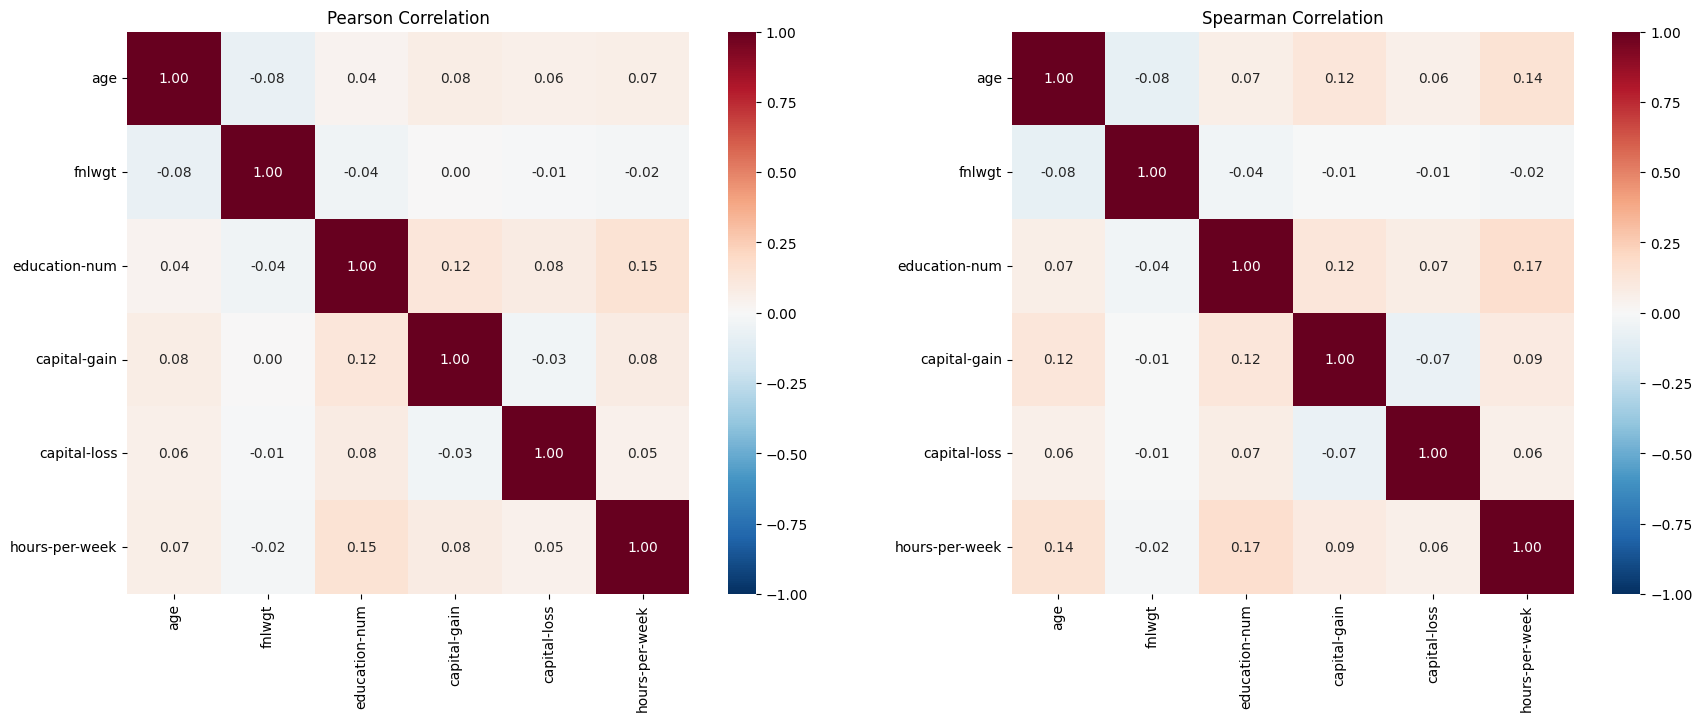

No feature pair has |r| > 0.9, so no very strong multicollinearity was detected.


In [17]:
# b) Pearson and Spearman heatmaps + strong multicollinearity check.
num_df = train_df[numeric_cols].copy()

pearson_corr = num_df.corr(method="pearson")
spearman_corr = num_df.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(
    pearson_corr,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    ax=axes[0],
)
axes[0].set_title("Pearson Correlation")

sns.heatmap(
    spearman_corr,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    ax=axes[1],
)
axes[1].set_title("Spearman Correlation")

plt.tight_layout()
plt.show()

def extract_high_corr_pairs(corr_matrix, method_name, threshold=0.9):
    rows = []
    cols = corr_matrix.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > threshold:
                rows.append(
                    {
                        "method": method_name,
                        "feature_1": cols[i],
                        "feature_2": cols[j],
                        "corr": r,
                        "abs_corr": abs(r),
                    }
                )
    return rows

pair_rows = (
    extract_high_corr_pairs(pearson_corr, "Pearson", 0.9)
    + extract_high_corr_pairs(spearman_corr, "Spearman", 0.9)
)

if pair_rows:
    high_pairs = pd.DataFrame(pair_rows).sort_values("abs_corr", ascending=False)
    print("Feature pairs with |r| > 0.9:")
    display(high_pairs)
else:
    high_pairs = pd.DataFrame(columns=["method", "feature_1", "feature_2", "corr", "abs_corr"])
    print("No feature pair has |r| > 0.9, so no very strong multicollinearity was detected.")

**Insights:**

- Không có cặp đặc trưng nào có tương quan mạnh với nhau. Đa phần các hệ số tương quan dù tính bằng **Pearson** hay **Spearman** đều có hệ số tương quan bé hơn 0.3.

## c. Phân tích missing data bằng `missingno` và kiểm định Little's MCAR.

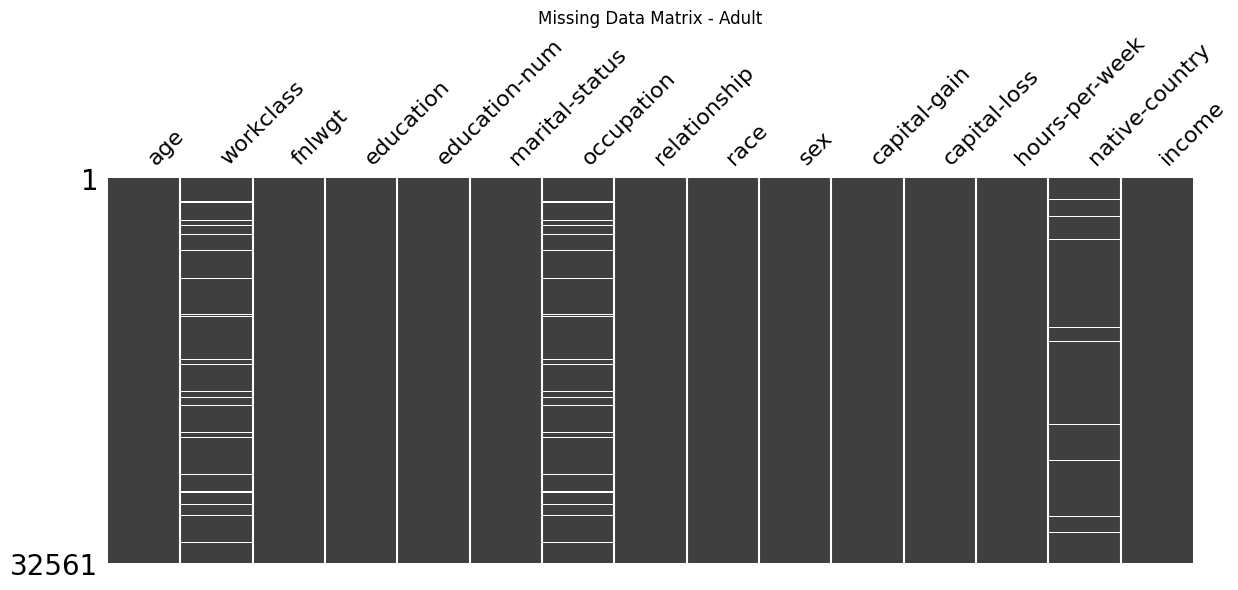

Little's MCAR test p-value: 0
Little test conclusion: Reject H0: missingness is NOT MCAR

Significant links between missingness and observed variables (p < 0.05):


,missing_col,predictor,test,p_value
5,workclass,occupation,chi-square,0.000000e+00
15,occupation,workclass,chi-square,0.000000e+00
25,occupation,hours-per-week,point-biserial,8.863553e-208
11,workclass,hours-per-week,point-biserial,2.710679e-206
20,occupation,relationship,chi-square,8.381720e-77
6,workclass,relationship,chi-square,7.397951e-75
36,native-country,race,chi-square,7.888172e-69
19,occupation,marital-status,chi-square,2.820650e-62
4,workclass,marital-status,chi-square,4.045450e-62
17,occupation,education,chi-square,4.146568e-56



Missing data mechanism: MAR (most plausible)
Explanation: Little test rejects MCAR and missingness is associated with observed variables, which is consistent with MAR.


In [18]:
# c) Missing data matrix + Little's MCAR test + missing mechanism inference.
msno.matrix(train_df, figsize=(14, 5), sparkline=False)
plt.title("Missing Data Matrix - Adult")
plt.show()

# pyampute Little's test needs numeric data; encode categorical columns while preserving NaN.
df_for_little = train_df.copy()
for c in df_for_little.columns:
    if c not in numeric_cols:
        cat = df_for_little[c].astype("category")
        df_for_little[c] = cat.cat.codes.replace(-1, np.nan).astype(float)

mcar_test = MCARTest(method="little")
little_p = mcar_test.little_mcar_test(df_for_little)

print(f"Little's MCAR test p-value: {little_p:.6g}")

if little_p > 0.05:
    little_conclusion = "Fail to reject H0: missingness can be MCAR"
else:
    little_conclusion = "Reject H0: missingness is NOT MCAR"

print("Little test conclusion:", little_conclusion)

# Differentiate MAR/MNAR by testing whether missing indicators depend on observed variables.
missing_cols = [c for c in train_df.columns if train_df[c].isna().any()]
association_rows = []

for mcol in missing_cols:
    miss_ind = train_df[mcol].isna().astype(int)

    for other_col in train_df.columns:
        if other_col == mcol:
            continue

        try:
            if other_col in numeric_cols:
                valid = train_df[other_col].notna()
                if valid.sum() > 10 and miss_ind[valid].nunique() > 1:
                    _, p = stats.pointbiserialr(miss_ind[valid], train_df.loc[valid, other_col].astype(float))
                    association_rows.append(
                        {
                            "missing_col": mcol,
                            "predictor": other_col,
                            "test": "point-biserial",
                            "p_value": p,
                        }
                    )
            else:
                temp = pd.DataFrame(
                    {
                        "miss": miss_ind,
                        "cat": train_df[other_col].fillna("<NA>").astype(str),
                    }
                )
                ctab = pd.crosstab(temp["miss"], temp["cat"])
                if ctab.shape[0] == 2 and ctab.shape[1] >= 2:
                    _, p, _, _ = stats.chi2_contingency(ctab)
                    association_rows.append(
                        {
                            "missing_col": mcol,
                            "predictor": other_col,
                            "test": "chi-square",
                            "p_value": p,
                        }
                    )
        except Exception:
            continue

assoc_df = pd.DataFrame(association_rows)

if not assoc_df.empty:
    sig_assoc = assoc_df[assoc_df["p_value"] < 0.05].sort_values("p_value")
    print("\nSignificant links between missingness and observed variables (p < 0.05):")
    display(sig_assoc.head(30))
else:
    sig_assoc = pd.DataFrame()
    print("\nNo additional dependency test was produced.")

if little_p > 0.05:
    mechanism = "MCAR (plausible)"
    explanation = "Little test does not reject MCAR, so there is no strong evidence that missingness depends on observed data."
else:
    if sig_assoc.empty:
        mechanism = "MNAR (suspected)"
        explanation = "Little test rejects MCAR but no clear dependency with observed variables was found; missingness may depend on unobserved values (MNAR)."
    else:
        mechanism = "MAR (most plausible)"
        explanation = "Little test rejects MCAR and missingness is associated with observed variables, which is consistent with MAR."

print("\nMissing data mechanism:", mechanism)
print("Explanation:", explanation)

**Insights:**

- Little's MCAR test cho p-value rất nhỏ, nên **bác bỏ giả thuyết MCAR**.
- Missingness có liên hệ có ý nghĩa với nhiều biến quan sát được, vì vậy cơ chế thiếu phù hợp nhất là **MAR**.
- Với cơ chế MAR, nên dùng các phương pháp bù thiếu tận dụng thông tin từ biến khác (MICE, iterative imputer, hoặc mô hình phân lớp cho missing indicator).

In [19]:
# Compact summary for reporting.
print("=== 1) Numeric distribution ===")
summary_dist = dist_result[["feature", "test", "p_value", "distribution", "recommended_scaling"]].copy()
summary_dist["p_value"] = summary_dist["p_value"].map(lambda x: f"{x:.3e}")
print(summary_dist.to_string(index=False))

print("\n=== 2) Multivariate correlation ===")
max_pearson = pearson_corr.where(~np.eye(len(pearson_corr), dtype=bool)).abs().max().max()
max_spearman = spearman_corr.where(~np.eye(len(spearman_corr), dtype=bool)).abs().max().max()
print(f"Max |Pearson r| (off-diagonal): {max_pearson:.4f}")
print(f"Max |Spearman r| (off-diagonal): {max_spearman:.4f}")
print("Number of pairs with |r| > 0.9:", len(high_pairs))

print("\n=== 3) Missing data ===")
missing_rate = (train_df.isna().mean() * 100).sort_values(ascending=False)
print("Missing rate (%):")
print(missing_rate[missing_rate > 0].round(3).to_string())

if "sig_assoc" in globals() and not sig_assoc.empty:
    top_assoc = sig_assoc[["missing_col", "predictor", "test", "p_value"]].copy().head(15)
    top_assoc["p_value"] = top_assoc["p_value"].map(lambda x: f"{x:.3e}")
    print("\nTop significant missingness links (p < 0.05):")
    print(top_assoc.to_string(index=False))

=== 1) Numeric distribution ===
       feature               test    p_value distribution                 recommended_scaling
           age D'Agostino-Pearson  0.000e+00   Non-normal RobustScaler or QuantileTransformer
        fnlwgt D'Agostino-Pearson  0.000e+00   Non-normal RobustScaler or QuantileTransformer
  capital-gain D'Agostino-Pearson  0.000e+00   Non-normal RobustScaler or QuantileTransformer
  capital-loss D'Agostino-Pearson  0.000e+00   Non-normal RobustScaler or QuantileTransformer
hours-per-week D'Agostino-Pearson  0.000e+00   Non-normal RobustScaler or QuantileTransformer
 education-num D'Agostino-Pearson 3.590e-178   Non-normal RobustScaler or QuantileTransformer

=== 2) Multivariate correlation ===
Max |Pearson r| (off-diagonal): 0.1481
Max |Spearman r| (off-diagonal): 0.1672
Number of pairs with |r| > 0.9: 0

=== 3) Missing data ===
Missing rate (%):
occupation        5.660
workclass         5.639
native-country    1.790

Top significant missingness links (p < 0.05)

**Insights:**

- Tất cả biến số đều không tuân theo phân phối chuẩn theo kiểm định thống kê.
- Tương quan tuyến tính và đơn điệu giữa các biến số đều thấp, chưa thấy rủi ro đa cộng tuyến mạnh.
- Xác nhận hướng xử lý tiền xử lý phù hợp: robust/quantile scaling cho biến số và imputation theo cơ chế MAR.